--- Lineer Regresyon Performansı ---
R2 Skoru: 0.9908
RMSE: 12423.63 Milyon $

--- Random Forest Performansı ---
R2 Skoru: 0.9814
RMSE: 17724.25 Milyon $



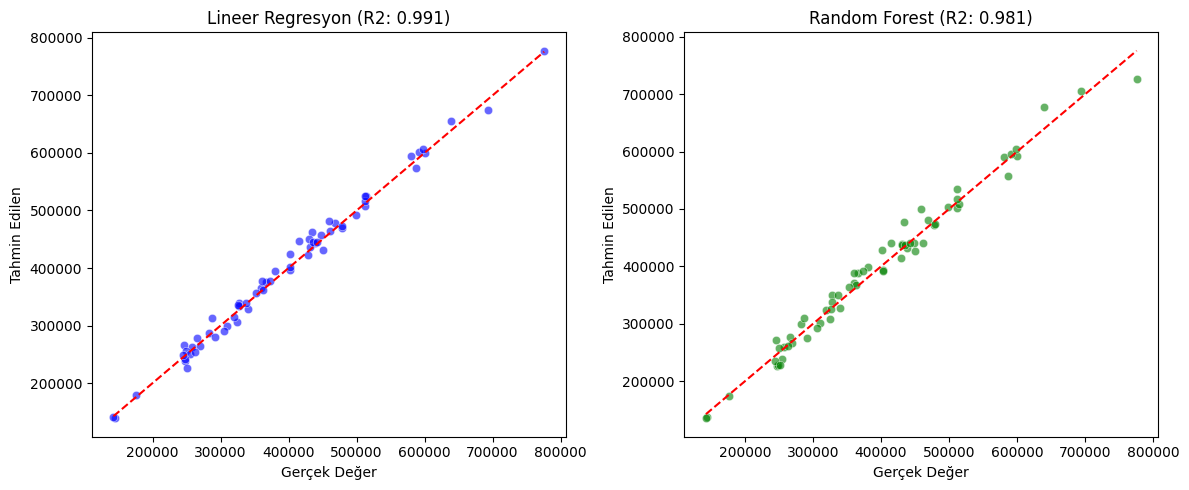

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# 1. VERİ YÜKLEME
file_name = '/Cleaned data.csv'

df = pd.read_csv(file_name)

# 2. VERİ HAZIRLIĞI
# Gereksiz veya hedef değişkenle çakışan kolonları çıkarıyoruz
X = df.drop(['Sum of Economic Loss (Million $)', 'Food Category', 'Year Category'], axis=1)
X = pd.get_dummies(X, columns=['Country'], drop_first=True)
y = df['Sum of Economic Loss (Million $)']

# Eğitim ve Test Seti Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. MODEL 1: LİNEER REGRESYON
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# 4. MODEL 2: RANDOM FOREST
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# 5. METRİKLERİN KARŞILAŞTIRILMASI
def get_metrics(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {name} Performansı ---")
    print(f"R2 Skoru: {r2:.4f}")
    print(f"RMSE: {rmse:.2f} Milyon $\n")
    return r2, rmse

lr_r2, lr_rmse = get_metrics(y_test, y_pred_lr, "Lineer Regresyon")
rf_r2, rf_rmse = get_metrics(y_test, y_pred_rf, "Random Forest")

# 6. GÖRSELLEŞTİRME
plt.figure(figsize=(12, 5))

# Hata Grafiği (Linear Regression)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Lineer Regresyon (R2: {lr_r2:.3f})')
plt.xlabel('Gerçek Değer')
plt.ylabel('Tahmin Edilen')

# Hata Grafiği (Random Forest)
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_rf, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Random Forest (R2: {rf_r2:.3f})')
plt.xlabel('Gerçek Değer')
plt.ylabel('Tahmin Edilen')

plt.tight_layout()
plt.show()